In [2]:
import cv2
import os
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

def show_image(I, gray=True):
    plt.figure()
    if gray:
        plt.imshow(I,'gray')
    else:
        plt.imshow(I)
    plt.axis('off')

Using device: cuda


In [3]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        #out_shape = (in_shape-kernel+2*padding)/stride + 1
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 128->64
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 64->32
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 32->16
            nn.ReLU()
        )

    def forward(self, x):
        return self.encoder(x)
        

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(x)

class CAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

In [4]:
class CableTrainDataset(Dataset):
    def __init__(self, files, images_size=1024, patch_size=128, stride=64):
        self.files = files
        self.images_size = images_size
        self.patch_size = patch_size
        self.stride = stride

        self.images = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in self.files]

        self.patch_map = []
        for img_id, _ in enumerate(self.images):
            for y in range(0, self.images_size - self.patch_size + 1, self.stride):
                for x in range(0, self.images_size - self.patch_size + 1, self.stride):
                    self.patch_map.append((img_id, y, x))

    def __len__(self):
        return len(self.patch_map)

    def __getitem__(self, idx):
        img_id, y, x = self.patch_map[idx]

        patch = self.images[img_id][y:y+128, x:x+128]
        patch = patch.astype(np.float32) / 255.0
        patch = np.expand_dims(patch, 0)

        return torch.tensor(patch)

In [5]:
folder = "cable/train/good"
files = [os.path.join(folder, f) for f in os.listdir(folder)]

train_files, temp_files = train_test_split(files, test_size=0.3, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=0.3, random_state=42)
print(len(train_files), len(val_files), len(test_files))

156 47 21


In [6]:
model = CAE()
train_dataset = CableTrainDataset(train_files)
val_dataset = CableTrainDataset(val_files)
test_dataset = CableTrainDataset(test_files)
print(len(train_dataset), len(val_dataset), len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) #, num_workers=4, pin_memory=True
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

35100 10575 4725


In [7]:
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

46529


In [8]:
model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

epochs = 20

for epoch in range(epochs):
    # TRAIN
    model.train()
    train_loss = 0

    for batch in train_loader:
        batch = batch.to(device)

        output = model(batch)                               
        loss = criterion(output, batch)

        optimizer.zero_grad()                      
        loss.backward()                                                         
        optimizer.step()                                        

        train_loss += loss.item()

    train_loss /= len(train_loader) 

    # VAL
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)

            output = model(batch)
            loss = criterion(output, batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch 1 | Train Loss: 0.002083 | Val Loss: 0.000342
Epoch 2 | Train Loss: 0.000315 | Val Loss: 0.000220
Epoch 3 | Train Loss: 0.000212 | Val Loss: 0.000157
Epoch 4 | Train Loss: 0.000174 | Val Loss: 0.000125
Epoch 5 | Train Loss: 0.000135 | Val Loss: 0.000125
Epoch 6 | Train Loss: 0.000121 | Val Loss: 0.000290
Epoch 7 | Train Loss: 0.000118 | Val Loss: 0.000120
Epoch 8 | Train Loss: 0.000097 | Val Loss: 0.000078
Epoch 9 | Train Loss: 0.000093 | Val Loss: 0.000072
Epoch 10 | Train Loss: 0.000093 | Val Loss: 0.000079
Epoch 11 | Train Loss: 0.000076 | Val Loss: 0.000064
Epoch 12 | Train Loss: 0.000075 | Val Loss: 0.000067
Epoch 13 | Train Loss: 0.000074 | Val Loss: 0.000058
Epoch 14 | Train Loss: 0.000068 | Val Loss: 0.000053
Epoch 15 | Train Loss: 0.000062 | Val Loss: 0.000073
Epoch 16 | Train Loss: 0.000059 | Val Loss: 0.000047
Epoch 17 | Train Loss: 0.000057 | Val Loss: 0.000046
Epoch 18 | Train Loss: 0.000056 | Val Loss: 0.000049
Epoch 19 | Train Loss: 0.000055 | Val Loss: 0.000046
Ep

In [9]:
model.eval()
test_loss = 0

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device, non_blocking=True)

        output = model(batch)
        loss = criterion(output, batch)

        test_loss += loss.item()

test_loss /= len(test_loader)

print(f"Test Loss: {test_loss:.6f}")

Test Loss: 0.000045


In [32]:
def reconstruct(image, patch_size=128, stride=64):
    model.eval()

    recon_map = np.zeros((1024, 1024), dtype=np.float32)
    count_map = np.zeros((1024, 1024), dtype=np.float32)

    with torch.no_grad():
        for y in range(0, 1024 - patch_size + 1, stride):
            for x in range(0, 1024 - patch_size + 1, stride):

                patch = image[y:y+patch_size, x:x+patch_size]
                patch = patch.astype(np.float32) / 255.0
                patch = np.expand_dims(patch, 0)  # channel
                patch = np.expand_dims(patch, 0)  # batch

                patch = torch.from_numpy(patch).to(device)
                recon = model(patch)
                recon = recon.cpu().numpy()[0, 0]

                recon_map[y:y+patch_size, x:x+patch_size] += recon
                count_map[y:y+patch_size, x:x+patch_size] += 1

    recon_map = recon_map/count_map

    return recon_map


def anomaly(image, patch_size=128, stride=64):
    model.eval()

    error_map = np.zeros((1024, 1024), dtype=np.float32)
    count_map = np.zeros((1024, 1024), dtype=np.float32)

    with torch.no_grad():
        for y in range(0, 1024 - patch_size + 1, stride):
            for x in range(0, 1024 - patch_size + 1, stride):

                patch = image[y:y+patch_size, x:x+patch_size]
                patch = patch.astype(np.float32) / 255.0
                patch = np.expand_dims(patch, 0)  # channel
                patch = np.expand_dims(patch, 0)  # batch

                patch = torch.from_numpy(patch).to(device)
                recon = model(patch)

                error = (patch - recon) ** 2
                error = error.cpu().numpy()[0, 0]

                error_map[y:y+patch_size, x:x+patch_size] += error
                count_map[y:y+patch_size, x:x+patch_size] += 1

    anomaly_map = error_map / count_map

    return anomaly_map

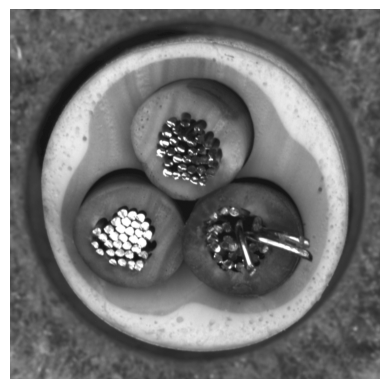

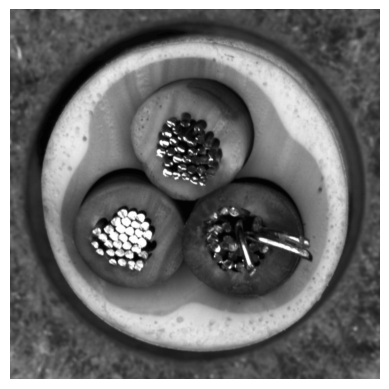

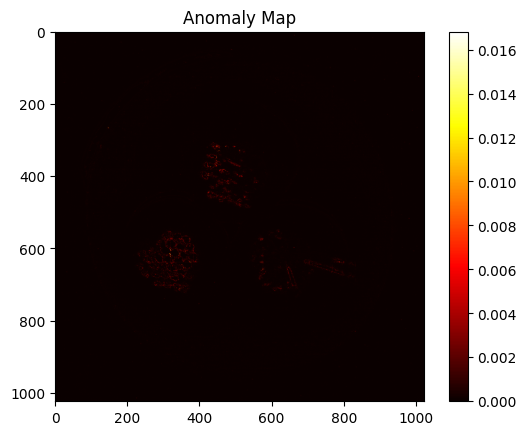

In [36]:
test_image = "cable/test/bent_wire/003.png"

I = cv2.imread(test_image, cv2.IMREAD_GRAYSCALE)
I_recon = (reconstruct(I) * 255).astype(np.uint8)
anomaly_map = anomaly(I)

show_image(I)
show_image(I_recon)
plt.figure()
plt.imshow(anomaly_map, cmap='hot')
plt.colorbar()
plt.title("Anomaly Map")
plt.show()